In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

In [ ]:
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
y=df['Churn'].value_counts()
y

,count
Churn,
No,5174
Yes,1869


**Data Preprocessing Part 1**

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.drop(columns='customerID',inplace=True)

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.duplicated().sum()

np.int64(22)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [ ]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.nunique()

,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,72
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3


In [ ]:
# checking the unique values in each columns

cols = df.columns
for i in cols:
  print(i,df[i].unique(),'\n')

gender ['Female' 'Male'] 

SeniorCitizen [0 1] 

Partner ['Yes' 'No'] 

Dependents ['No' 'Yes'] 

tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39] 

PhoneService ['No' 'Yes'] 

MultipleLines ['No phone service' 'No' 'Yes'] 

InternetService ['DSL' 'Fiber optic' 'No'] 

OnlineSecurity ['No' 'Yes' 'No internet service'] 

OnlineBackup ['Yes' 'No' 'No internet service'] 

DeviceProtection ['No' 'Yes' 'No internet service'] 

TechSupport ['No' 'Yes' 'No internet service'] 

StreamingTV ['No' 'Yes' 'No internet service'] 

StreamingMovies ['No' 'Yes' 'No internet service'] 

Contract ['Month-to-month' 'One year' 'Two year'] 

PaperlessBilling ['Yes' 'No'] 

PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)'] 

MonthlyCharges [29.85 56.95 53.85 ... 63.1  44.2  78.7

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7010.000000,7010.000000,7010.000000,7010.000000
mean,0.162767,32.520399,64.888666,2290.353388
std,0.369180,24.520441,30.064769,2266.820832
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.750000,408.312500
50%,0.000000,29.000000,70.400000,1403.875000
75%,0.000000,56.000000,89.900000,3807.837500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df['gender'].value_counts()

,count
gender,
Male,3535
Female,3475


In [ ]:
df['SeniorCitizen'].value_counts()

,count
SeniorCitizen,
0,5869
1,1141


**Exploratory Data Analysis**

In [ ]:
## Customer Demographics

Text(0.5, 1.0, 'Dependents')

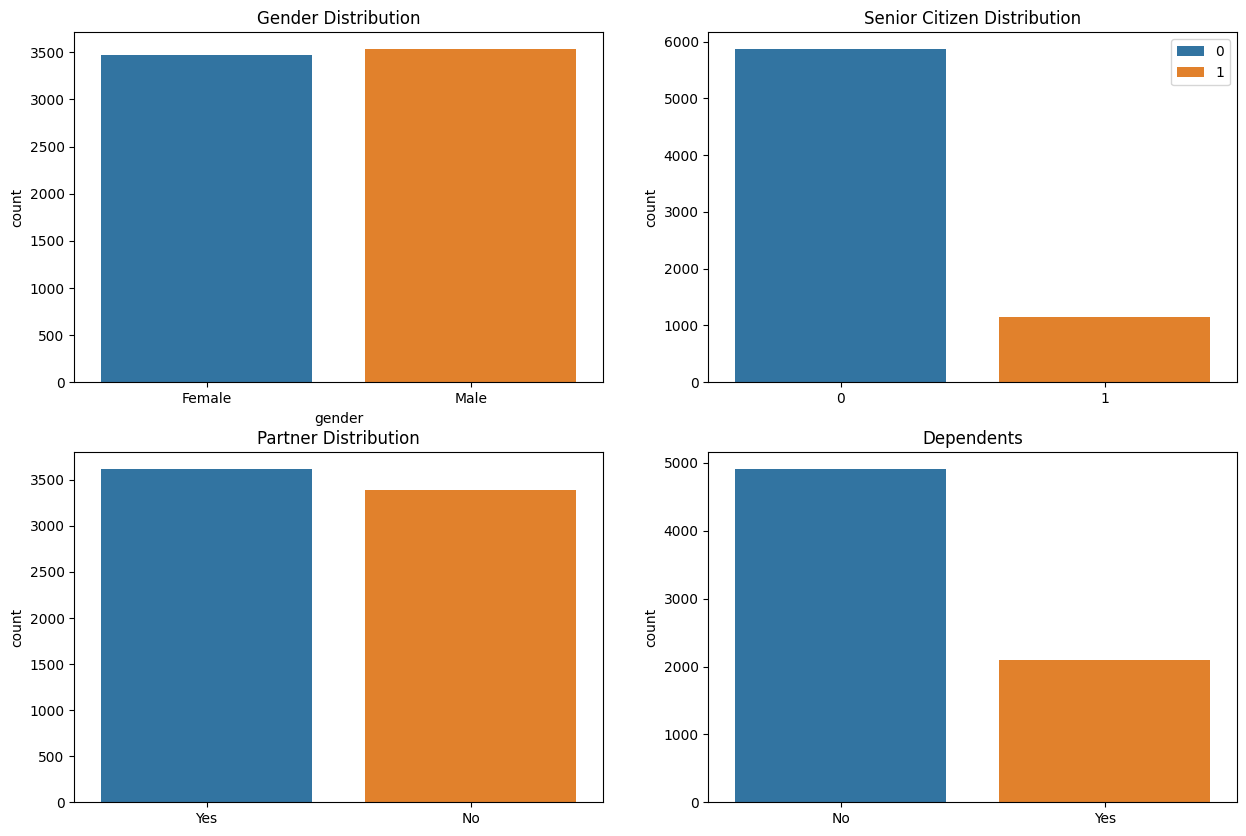

In [ ]:
fig , ax =plt.subplots(2,2,figsize=(15,10))

# Gender Distribution

# ax[0,0].pie(df['gender'].value_counts(),labels=['Male','Female'],autopct='%1.2f%%')
# ax[0,0].set_title('Gender Distribution')
sns.countplot(x=df['gender'],hue=df["gender"],ax=ax[0,0]).set_title("Gender Distribution")

# Senior Citizen Distribution
sns.barplot(y=df['SeniorCitizen'].value_counts(),x=df['SeniorCitizen'].unique(),hue=df['SeniorCitizen'].unique(),ax=ax[0,1]).set_title('Senior Citizen Distribution')

# Partner Distribution
sns.barplot(y=df['Partner'].value_counts(),x=df['Partner'].unique(),hue=df['Partner'].unique(),ax=ax[1,0]).set_title('Partner Distribution')

#Dependents Distribution
sns.barplot(y = df['Dependents'].value_counts(), x = df['Dependents'].unique(),hue=df['Dependents'].unique(), ax=ax[1,1]).set_title('Dependents')


#**Services**

Text(0.5, 1.0, 'Streaming Movies')

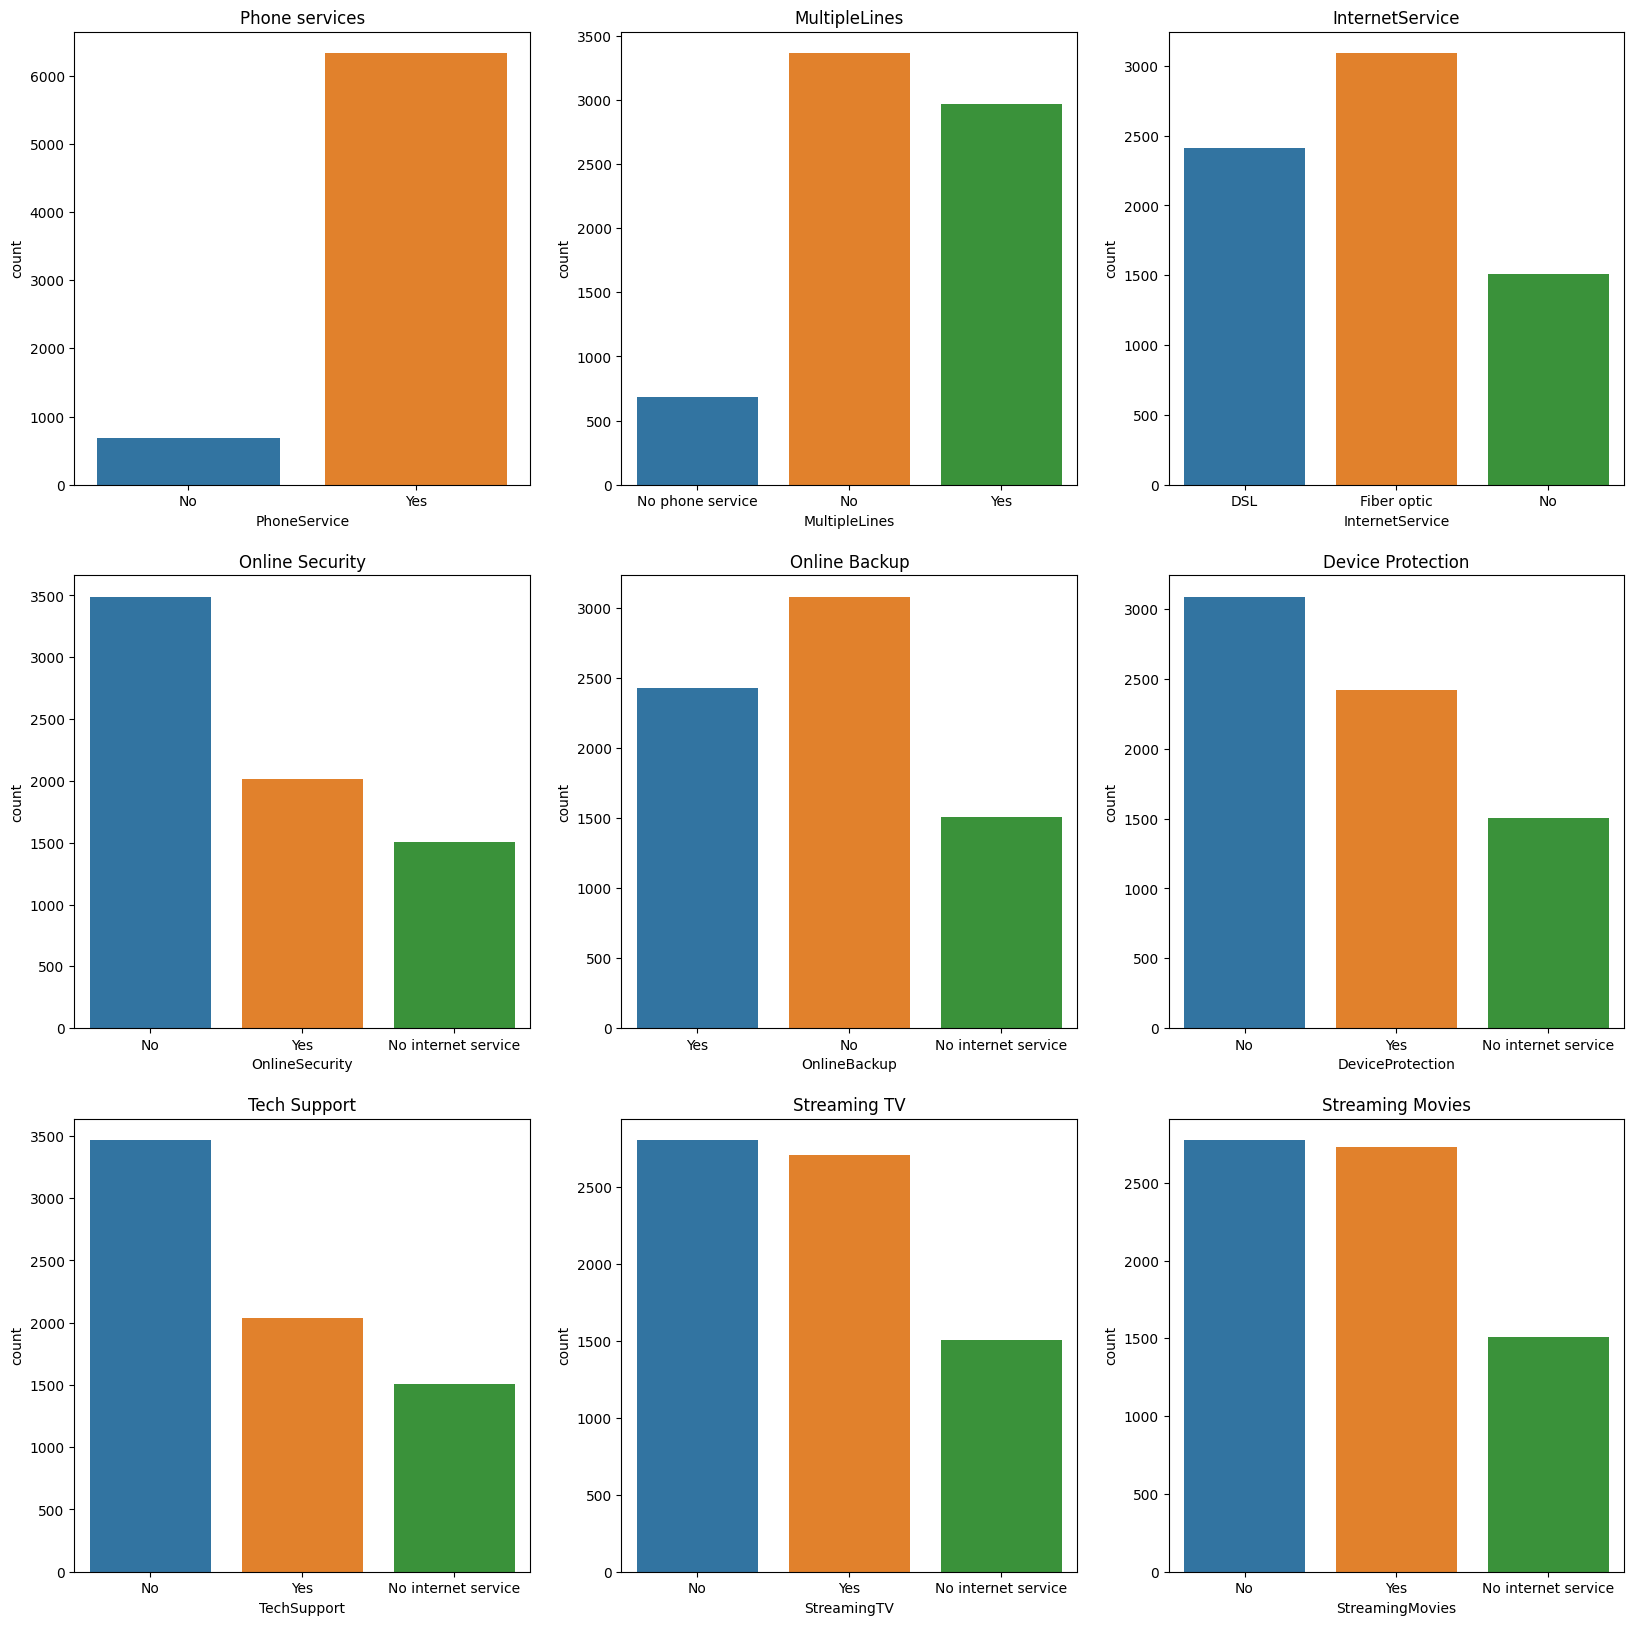

In [ ]:
fig,ax=plt.subplots(3,3,figsize=(20,20))
#phone services
sns.countplot(x=df['PhoneService'],hue=df['PhoneService'],ax=ax[0,0]).set_title("Phone services")

#Multiple Lines
sns.countplot(x=df['MultipleLines'],hue=df['MultipleLines'],ax=ax[0,1]).set_title("MultipleLines")

#Internet Services
sns.countplot(x=df['InternetService'],hue=df['InternetService'],ax=ax[0,2]).set_title("InternetService")

#Online Security
sns.countplot(x = df['OnlineSecurity'],hue=df['OnlineSecurity'], ax=ax[1,0]).set_title('Online Security')
ax[1,0].set_title('Online Security')

#Online Backup
sns.countplot(x = df['OnlineBackup'],hue=df['OnlineBackup'], ax=ax[1,1]).set_title('Online Backup')
ax[1,1].set_title('Online Backup')

#Device Protection
sns.countplot(x = df['DeviceProtection'],hue=df['DeviceProtection'], ax=ax[1,2]).set_title('Device Protection')
ax[1,2].set_title('Device Protection')

#Tech Support
sns.countplot(x = df['TechSupport'],hue=df['TechSupport'], ax=ax[2,0]).set_title('Tech Support')
ax[2,0].set_title('Tech Support')

#Streaming TV
sns.countplot(x = df['StreamingTV'],hue=df['StreamingTV'], ax=ax[2,1]).set_title('Streaming TV')
ax[2,1].set_title('Streaming TV')

#Streaming Movies
sns.countplot(x = df['StreamingMovies'],hue=df['StreamingMovies'], ax=ax[2,2]).set_title('Streaming Movies')
ax[2,2].set_title('Streaming Movies')

#**Tenure and Contract**

Text(0.5, 1.0, 'Contract Type')

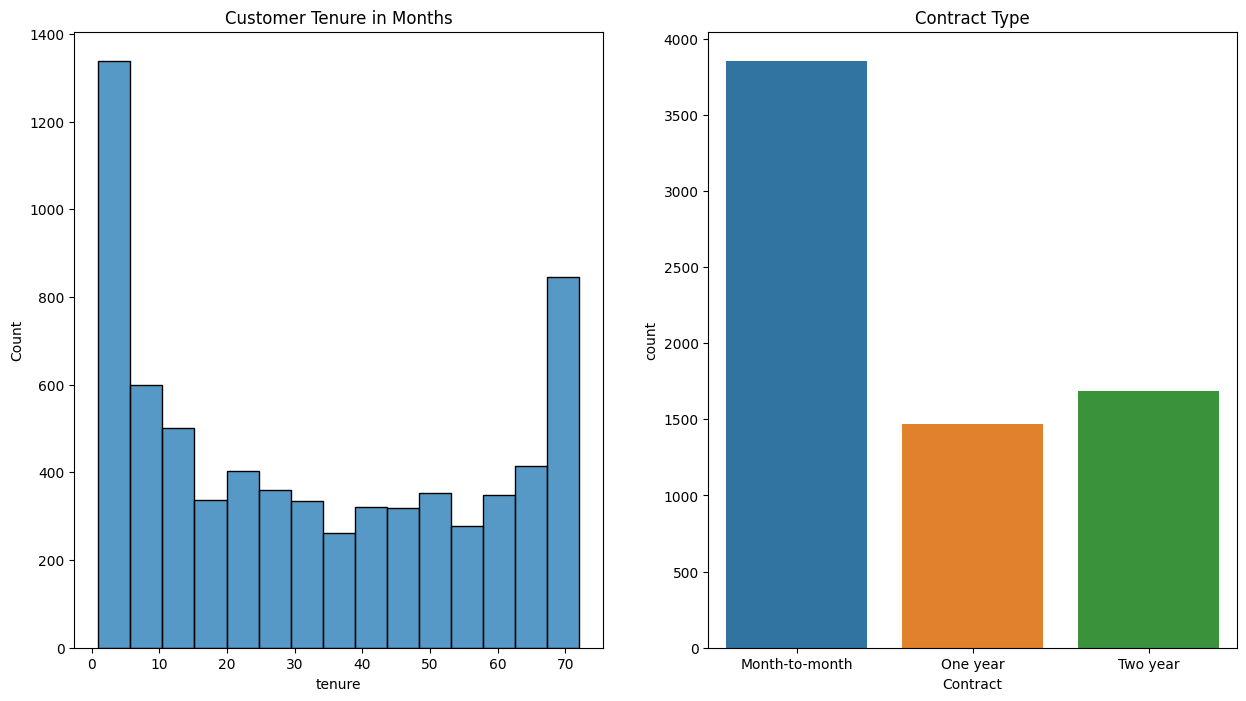

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(15,8))
sns.histplot(x=df['tenure'],ax=ax[0]).set_title("Customer Tenure in Months")
sns.countplot(x=df['Contract'],hue=df['Contract'],ax=ax[1]).set_title("Contract Type")

#**Billing and Charges**

Text(0.5, 1.0, 'Total Charges')

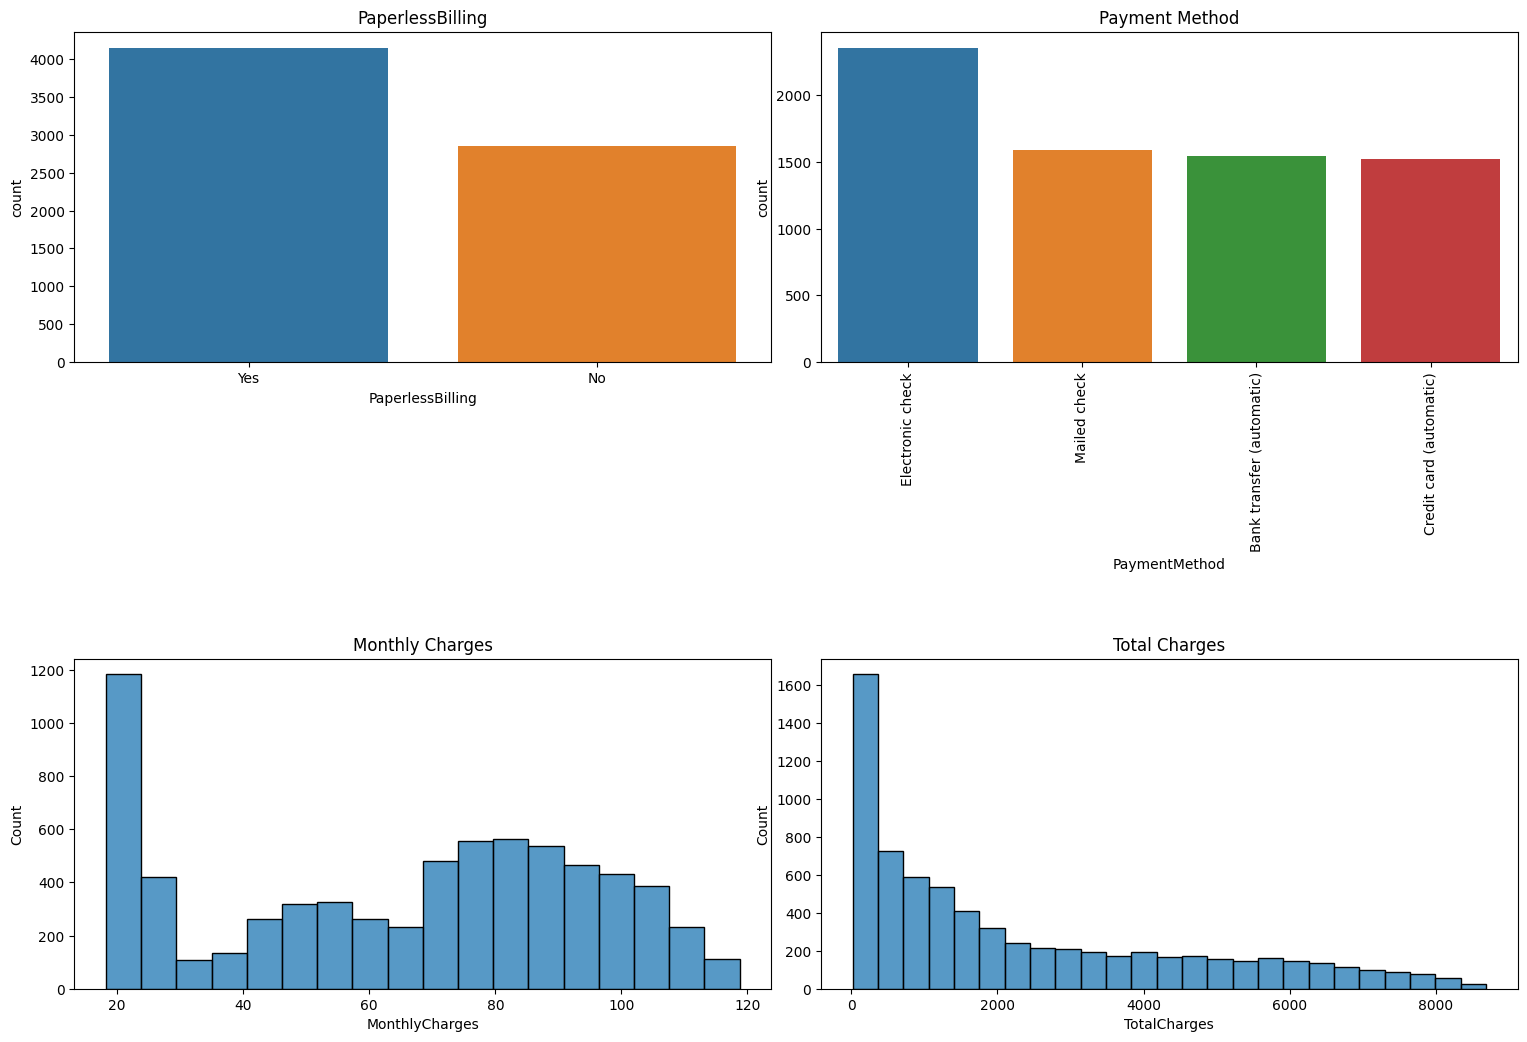

In [ ]:
fig,ax=plt.subplots(2,2,figsize=(15,10))
fig.tight_layout(pad=0.5)

#spacing between subplots
fig.subplots_adjust(hspace=0.9)

#paperless billing
sns.countplot(x=df['PaperlessBilling'],hue=df['PaperlessBilling'],ax=ax[0,0]).set_title('PaperlessBilling')

#Payment Method
sns.countplot(x = df['PaymentMethod'],hue=df['PaymentMethod'], ax=ax[0,1]).set_title('Payment Method')
ax[0,1].xaxis.set_tick_params(rotation=90)

#Monthly Charges
sns.histplot(x=df['MonthlyCharges'],ax=ax[1,0]).set_title("Monthly Charges")

#Total Charges
sns.histplot(x = 'TotalCharges', data = df, ax = ax[1,1]).set_title('Total Charges')

#**Churn Count**

Text(0.5, 1.0, 'Churn Count')

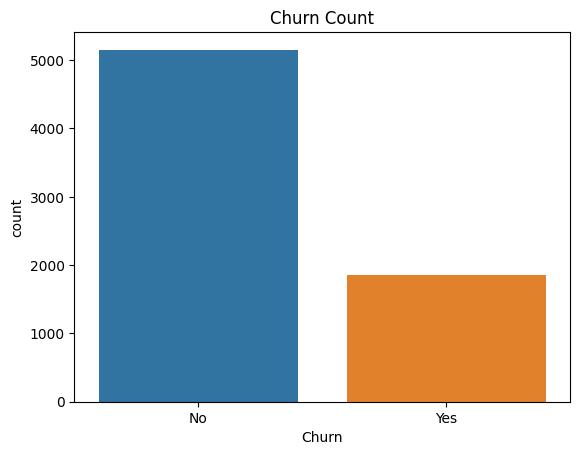

In [ ]:
# plt.pie(x=df['Churn'].value_counts(),labels=df['Churn'].unique(),autopct='%1.2f%%')
#plt.title("Churn Count")
sns.countplot(x=df["Churn"],hue=df["Churn"]).set_title("Churn Count")

Till now, I have visualized the data and got a better understanding of the data. Now, I will look at the relationship between the independent variables and the target variable.

#**Customer Demographics and Churn **

Text(0.5, 1.0, 'Dependents and Churn')

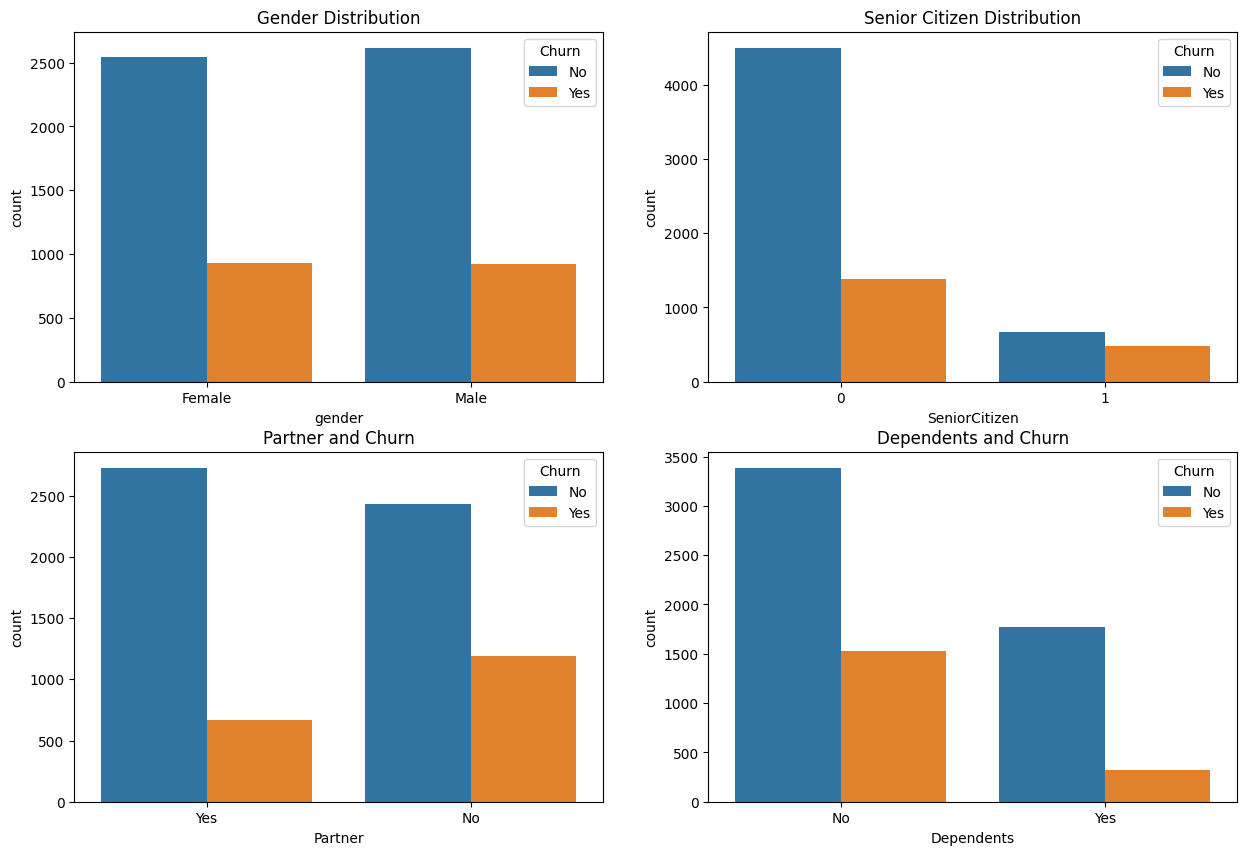

In [ ]:
fig,ax=plt.subplots(2,2,figsize=(15,10))

#Gender Distribution
sns.countplot(x=df['gender'],hue=df['Churn'],ax=ax[0,0]).set_title("Gender Distribution")

#Senior Citizen Distribution
sns.countplot(x=df['SeniorCitizen'],ax=ax[0,1],hue=df['Churn']).set_title("Senior Citizen Distribution")

#Partner Distribution
sns.countplot( x = df['Partner'], ax=ax[1,0], hue = df['Churn']).set_title('Partner and Churn')

#Dependents Distribution
sns.countplot(x = df['Dependents'], ax=ax[1,1], hue = df['Churn']).set_title('Dependents and Churn')


#**Services and Churn**

Text(0.5, 1.0, 'Streaming Movies')

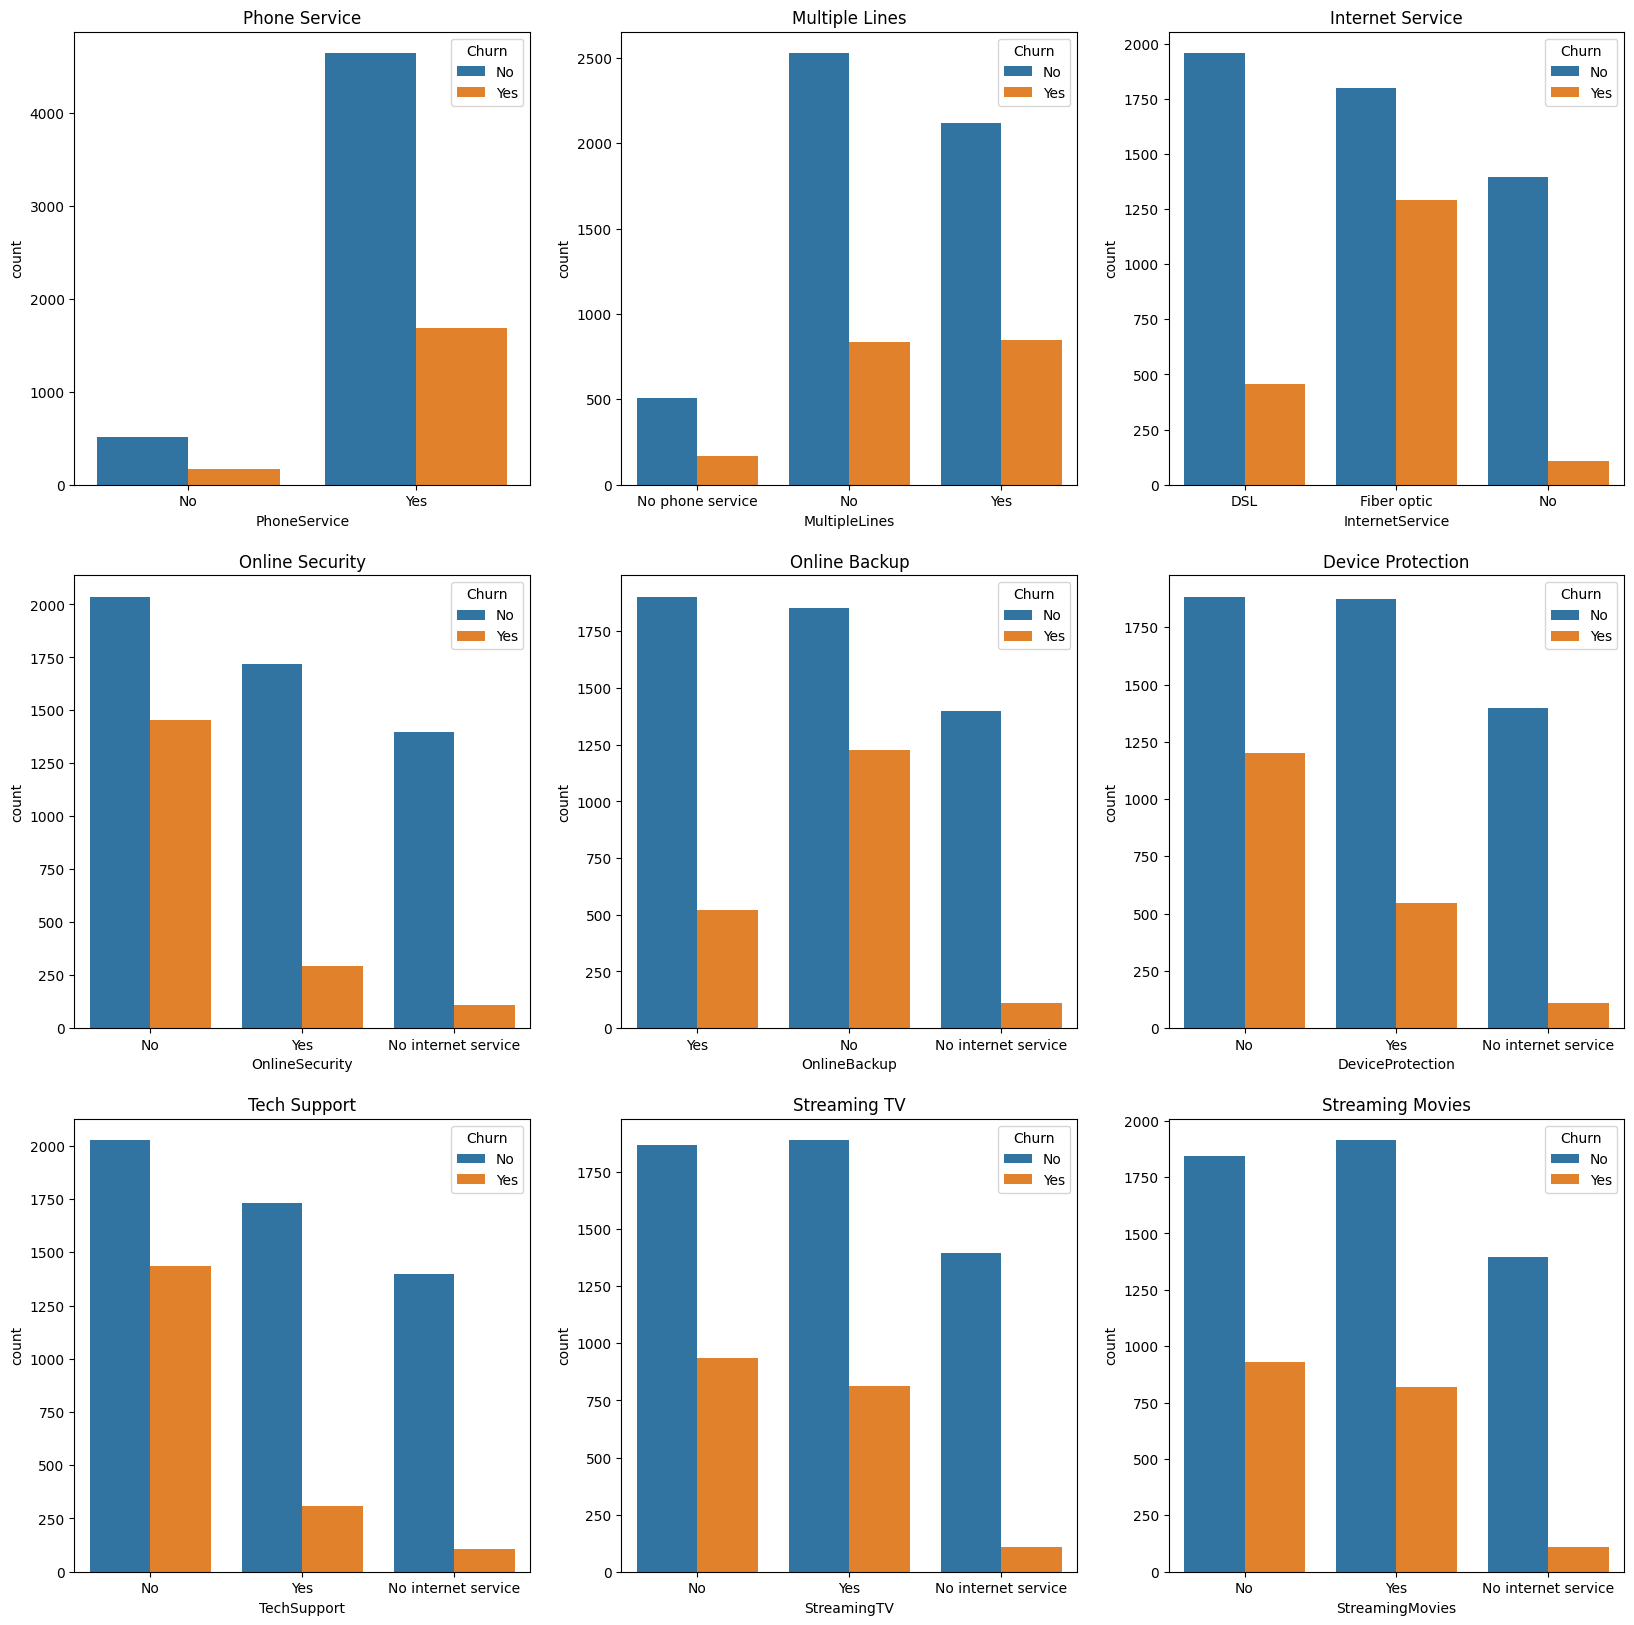

In [ ]:
fig, ax = plt.subplots(3, 3, figsize=(20, 20))
#phone service
sns.countplot(x = df['PhoneService'], ax=ax[0,0], hue = df['Churn']).set_title('Phone Service')
ax[0,0].set_title('Phone Service')
#Multiple Lines
sns.countplot(x = df['MultipleLines'], ax=ax[0,1], hue = df['Churn']).set_title('Multiple Lines')
ax[0,1].set_title('Multiple Lines')
#Internet Service
sns.countplot(x = df['InternetService'], ax=ax[0,2], hue = df['Churn']).set_title('Internet Service')
ax[0,2].set_title('Internet Service')
#Online Security
sns.countplot(x = df['OnlineSecurity'], ax=ax[1,0], hue = df['Churn']).set_title('Online Security')
ax[1,0].set_title('Online Security')
#Online Backup
sns.countplot(x = df['OnlineBackup'], ax=ax[1,1], hue = df['Churn']).set_title('Online Backup')
ax[1,1].set_title('Online Backup')
#Device Protection
sns.countplot(x = df['DeviceProtection'], ax=ax[1,2], hue = df['Churn']).set_title('Device Protection')
ax[1,2].set_title('Device Protection')
#Tech Support
sns.countplot(x = df['TechSupport'], ax=ax[2,0], hue = df['Churn']).set_title('Tech Support')
ax[2,0].set_title('Tech Support')
#Streaming TV
sns.countplot(x = df['StreamingTV'], ax=ax[2,1], hue = df['Churn']).set_title('Streaming TV')
ax[2,1].set_title('Streaming TV')
#Streaming Movies
sns.countplot(x = df['StreamingMovies'], ax=ax[2,2], hue = df['Churn']).set_title('Streaming Movies')
ax[2,2].set_title('Streaming Movies')

#**Tenure/Contract and Churn**

Text(0.5, 1.0, 'Contract Type and Churn')

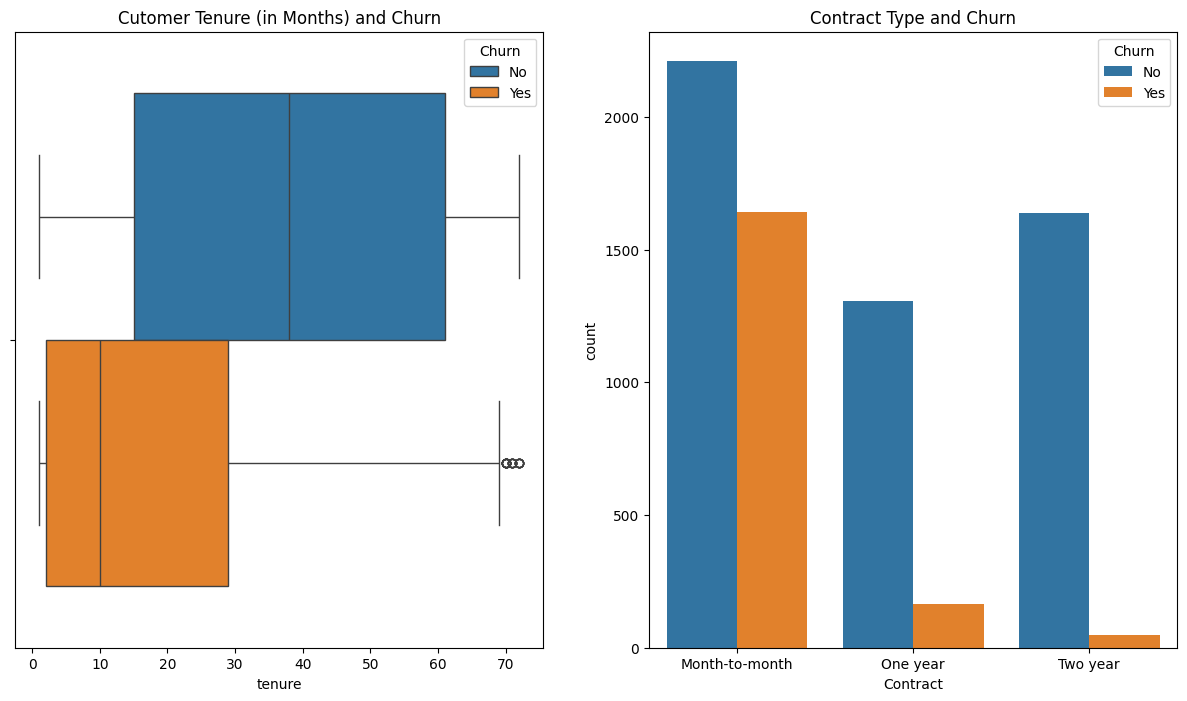

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(15, 8))
#sns.histplot(x = 'tenure', data = df, ax= ax[0], hue = 'Churn', multiple = 'stack').set_title('Cutomer Tenure (in Months) and Churn')
sns.boxplot(x = 'tenure', data = df, ax= ax[0], hue = 'Churn').set_title('Cutomer Tenure (in Months) and Churn')
sns.countplot(x = 'Contract', data = df, ax= ax[1], hue = 'Churn').set_title('Contract Type and Churn')

#Billing/Charges and churn

Text(0.5, 1.0, 'Total Charges')

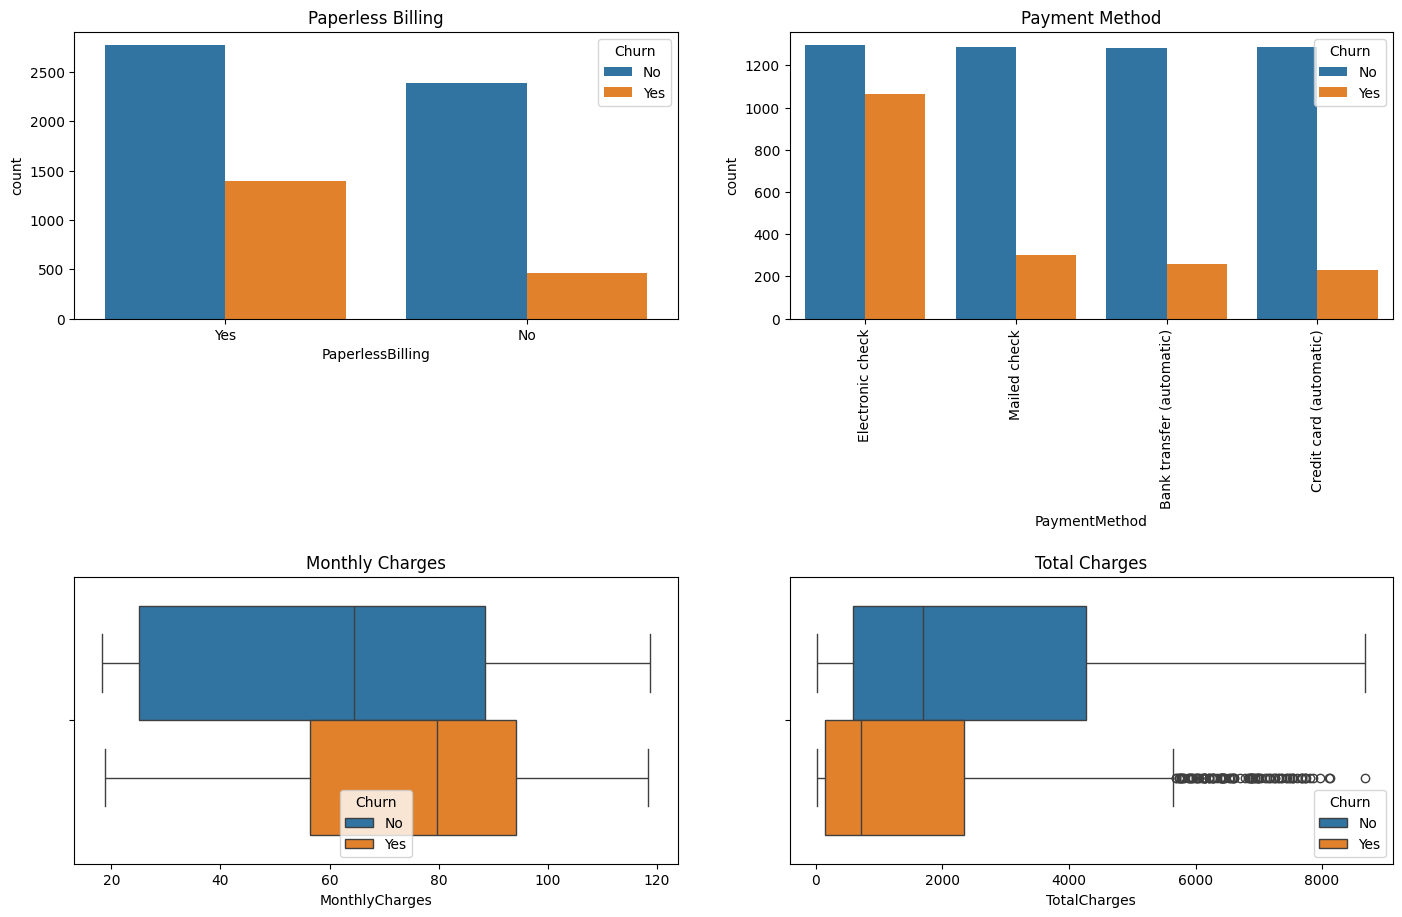

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
fig.tight_layout(pad=5.0)

#spacing between subplots
fig.subplots_adjust(hspace=0.9)


#papaerless billing
sns.countplot(x = df['PaperlessBilling'], ax=ax[0,0], hue = df['Churn']).set_title('Paperless Billing')

#Payment Method
sns.countplot(x = df['PaymentMethod'], ax=ax[0,1], hue = df['Churn']).set_title('Payment Method')
ax[0,1].xaxis.set_tick_params(rotation=90)

#Monthly Charges
sns.boxplot(x = 'MonthlyCharges', data = df, ax = ax[1,0], hue = 'Churn').set_title('Monthly Charges')

#Total Charges
sns.boxplot(x = 'TotalCharges', data = df, ax = ax[1,1], hue = 'Churn').set_title('Total Charges')

#**Data Preprocessing part 2**

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7010.000000,7010.000000,7010.000000,7010.000000
mean,0.162767,32.520399,64.888666,2290.353388
std,0.369180,24.520441,30.064769,2266.820832
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.750000,408.312500
50%,0.000000,29.000000,70.400000,1403.875000
75%,0.000000,56.000000,89.900000,3807.837500
max,1.000000,72.000000,118.750000,8684.800000


Outlier Removal

In [ ]:
cols=['tenure','MonthlyCharges','TotalCharges']

#Using IQR method to remove outliers

Q1=df[cols].quantile(0.25)
Q2=df[cols].quantile(0.50)
Q3=df[cols].quantile(0.75)
IQR=Q3-Q1

#Removing the outliers

df=df[~((df[cols]<(Q1-1.5*IQR))|(df[cols]>(Q3+1.5*IQR))).any(axis=1)]


In [ ]:
print("After removing outliers Shape : ", df.shape)

After removing outliers Shape :  (7010, 20)


#**Label Encoding**

In [ ]:
from sklearn.preprocessing import LabelEncoder

#columns for the label encoding

cols=df.columns[df.dtypes=='object']

#label encoder object
le=LabelEncoder()

#Label encoding the columns
for i in cols:
  le.fit(df[i])
  df[i]=le.transform(df[i])
  print(i,df[i].unique(),'\n')


gender [0 1] 

Partner [1 0] 

Dependents [0 1] 

PhoneService [0 1] 

MultipleLines [1 0 2] 

InternetService [0 1 2] 

OnlineSecurity [0 2 1] 

OnlineBackup [2 0 1] 

DeviceProtection [0 2 1] 

TechSupport [0 2 1] 

StreamingTV [0 2 1] 

StreamingMovies [0 2 1] 

Contract [0 1 2] 

PaperlessBilling [1 0] 

PaymentMethod [2 3 0 1] 

Churn [0 1] 



#**Feature Scaling**

In [ ]:
# df[['tenure','MonthlyCharges','TotalCharges']].std()

In [ ]:
#df[['tenure','MonthlyCharges','TotalCharges']].mean()

#**Correlation Matrix Heatmap**

<Axes: >

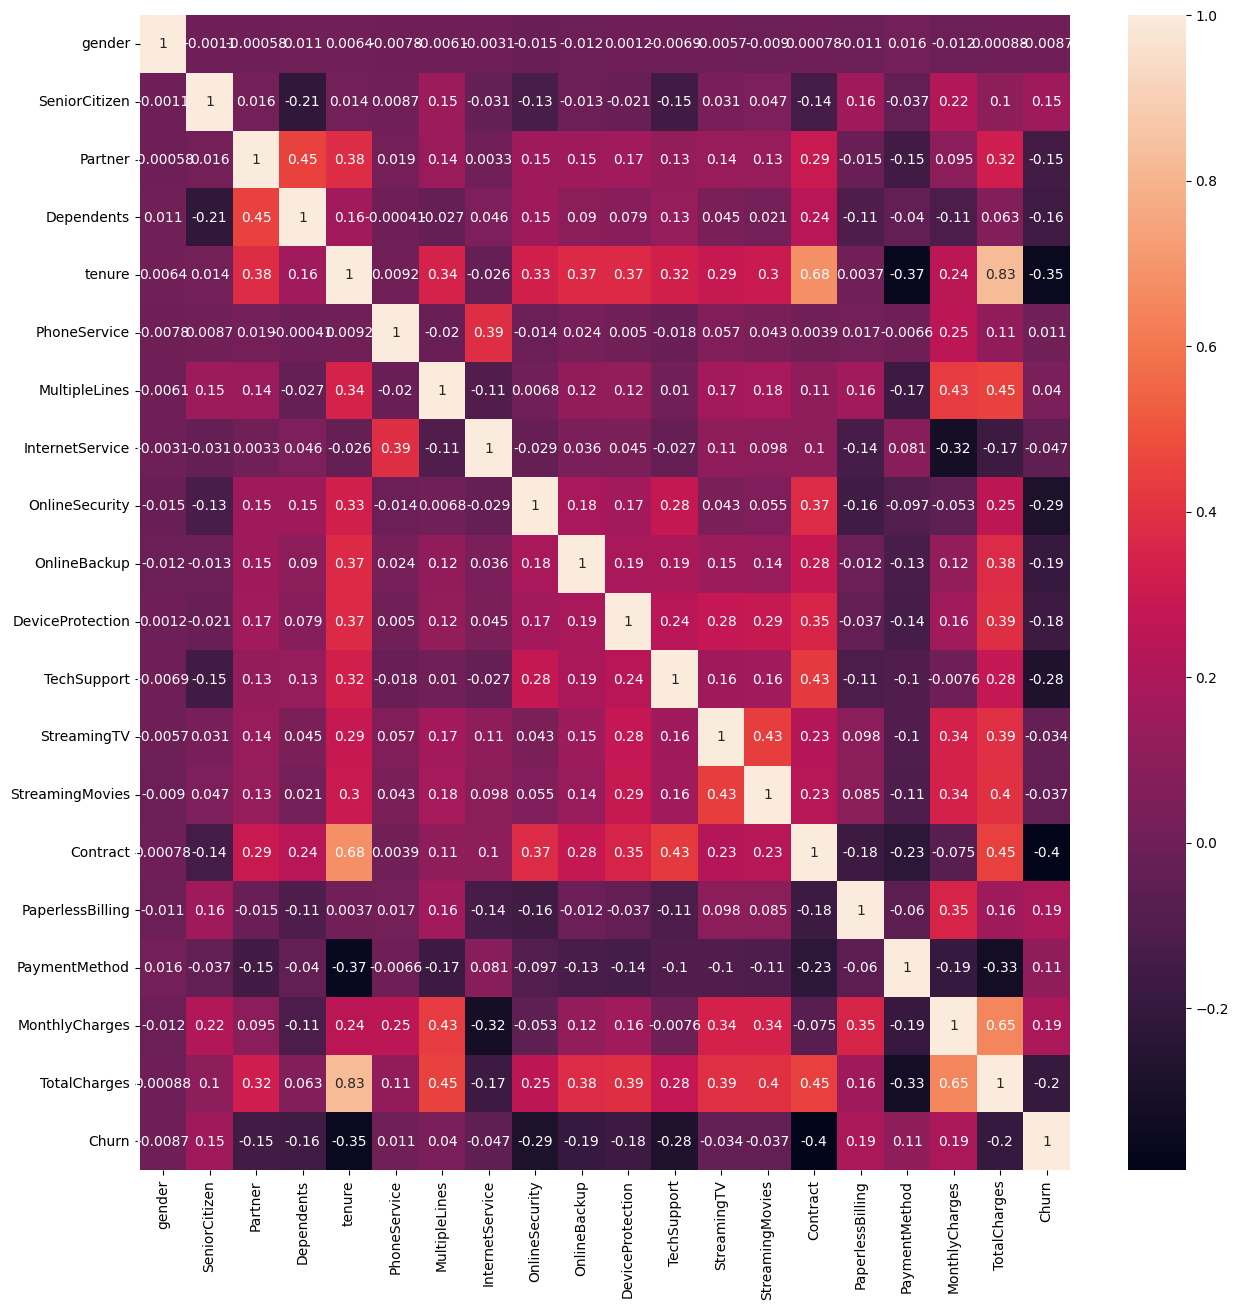

In [ ]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(),annot=True)

***Train Test Split***

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = sc.fit_transform(
    X_train[numeric_cols]
)

X_test_scaled[numeric_cols] = sc.transform(
    X_test[numeric_cols]
)

In [ ]:
X_train.shape

(5608, 19)

#**Model Building**

# 1. Logistic Regression

### Without Hyperparameter Tuning

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lor=LogisticRegression()
lor.fit(X_train_scaled,y_train)
lor_pred=lor.predict(X_test_scaled)

In [ ]:
accuracy_score(y_test,lor_pred)

0.8216833095577746

### With Hyperparameter Tuning

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

lr = LogisticRegression(max_iter=1000)

params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

grid = GridSearchCV(
    lr,
    params,
    cv=5,
    scoring="f1"
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
0.6027207179102486


In [ ]:
lr=LogisticRegression(max_iter=1000, C=10,penalty='l2',solver='liblinear')
lr.fit(X_train_scaled,y_train)
lr_pred=lr.predict(X_test_scaled)
accuracy_score(y_test,lr_pred)


0.8209700427960057

In [ ]:
f1_score(y_test,lr_pred)

0.5945072697899838

#**2. Decision Tree classifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
dtree=DecisionTreeClassifier()

Hyperparameter Tuning using GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

#parameter grid
param_grid={
    'max_depth':[2,4,6,8,10],
    'min_samples_leaf':[2,4,6,8,10],
    'min_samples_split':[2,4,6,8,10],
    'criterion':['gini','entropy'],
    'random_state':[0,42]
}

# Gridsearch Object with Decision Tree Classifier
grid_search = GridSearchCV(
    estimator=dtree,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

#Fitting the data
grid_search.fit(X_train,y_train)

#Best Parameters
print(grid_search.best_params_)

In [ ]:
#Decision Tree classifier with best parameters
dtree=DecisionTreeClassifier(criterion='gini',min_samples_leaf=8,min_samples_split=2,max_depth=6,random_state=0,)

# Fitting the data
dtree.fit(X_train,y_train)

#Training accuracy
print("training score: ", dtree.score(X_train,y_train))

#Predicting the values
d_pred=dtree.predict(X_test)

# Testing accuracy :
print("testing score  : ",accuracy_score(y_test,d_pred))

training score:  0.8045649072753209
testing score  :  0.7895863052781741


#*3. Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier()


Hyperparameter Tuning using Grid Search CV

In [ ]:
from sklearn.model_selection import GridSearchCV

#parameter grid
param_grid={
    'max_depth':[2,4,6,8,10],
    'min_samples_split':[2,4,6,8,10],
    'min_samples_leaf':[2,4,6,8,10],
    'criterion':['gini','entropy'],
    'random_state':[0,42]
}

#Grid Search Object with Random Forest Classifier
grid_search=GridSearchCV(estimator=rfc,param_grid=param_grid,cv=3,n_jobs=-1,verbose=2,scoring='accuracy')

#Fitting the data
grid_search.fit(X_train,y_train)

#Best parameters
print(grid_search.best_params_)

Fitting 3 folds for each of 500 candidates, totalling 1500 fits
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2, 'random_state': 42}


In [ ]:
#Random Forest classifier Object with best parameters
rfc=RandomForestClassifier(criterion='entropy', max_depth=10, min_samples_leaf=10, min_samples_split=2, random_state=42)

#Fitting the Data
rfc.fit(X_train,y_train)

#Training accuracy
print("Training accuracy : ",rfc.score(X_train,y_train))

#Predicting the values
r_pred=rfc.predict(X_test)

#Testing accuracy

print("Testing accuracy ; ",accuracy_score(y_test,r_pred))

Training accuracy :  0.8309557774607703
Testing accuracy ;  0.8202567760342369


#**4.K Nearest Neighbors Classifier**

### Without Hyperparameter Tuning

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

In [ ]:
accuracy_score(y_test,y_pred_knn)

In [ ]:
# from sklearn.neighbors import KNeighborsClassifier

# #KNN Classifier Object
# knn = KNeighborsClassifier()

Hyperparameter Tuning using GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

#parameter grid
param_grid = {
    'n_neighbors': [2,4,6,8,10],
    'weights': ['uniform', 'distance'],
     'metric': ['euclidean', 'manhattan']

}

#Grid Search Object with KNN Classifier
grid_search = GridSearchCV(estimator = knn, param_grid = param_grid, cv = 3, n_jobs = -1, verbose = 2, scoring='accuracy')

#Fitting the data
grid_search.fit(X_train_scaled, y_train)

#Best parameters
print(grid_search.best_params_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
{'algorithm': 'auto', 'n_neighbors': 6, 'weights': 'uniform'}


In [ ]:
#KNN Classifier Object with best parameters
# knn = KNeighborsClassifier(algorithm='ball_tree', n_neighbors=8, weights='uniform')

# #Fitting the data
# knn.fit(X_train_scaled, y_train)

# #Training accuracy
# print('Training Accuracy: ', knn.score(X_train, y_train))

# #Predicting the values
# k_pred = knn.predict(X_test_scaled)

# #Testing accuracy
# print('Testing Accuracy: ', accuracy_score(y_test, k_pred))


Training Accuracy:  0.8127674750356634
Testing Accuracy:  0.7860199714693296


#**Model Evaluation**

**Confusion Matrix Heatmap**

Text(0.5, 1.0, 'KNN Confusion Matrix')

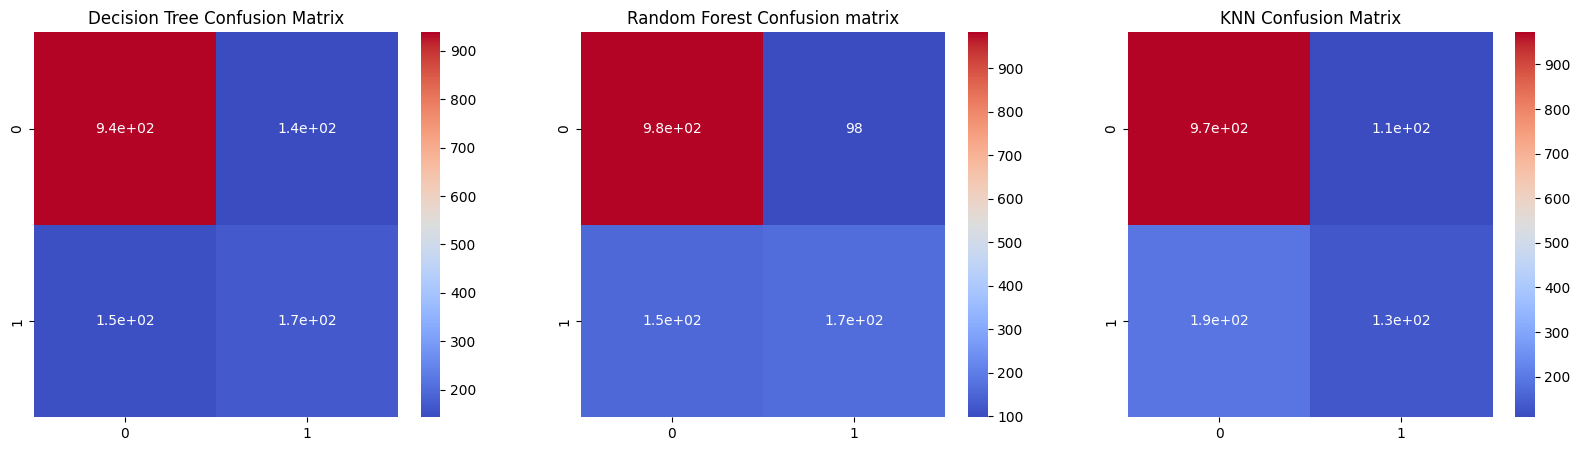

In [ ]:
from sklearn.metrics import confusion_matrix

fig,ax=plt.subplots(1,3,figsize=(20,5))

#Decision Tree Confusion Matrix
sns.heatmap(confusion_matrix(y_test,d_pred),annot=True,ax=ax[0],cmap='coolwarm').set_title('Decision Tree Confusion Matrix')

#Random Forest Confustion matrix
sns.heatmap(confusion_matrix(y_test,r_pred),annot=True,ax=ax[1],cmap='coolwarm').set_title("Random Forest Confusion matrix")

#KNN Confusion Matrix
sns.heatmap(confusion_matrix(y_test,k_pred),annot=True,ax=ax[2],cmap='coolwarm').set_title("KNN Confusion Matrix")


#**Distribution Plot**

/tmp/ipykernel_659/1088561144.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test,hist=False,color="r",label="Actual Value",ax=ax[0,0]).set_title("Logistic Regression")
/tmp/ipykernel_659/1088561144.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(lor_pred,hist=False,

<Axes: title={'center': 'KNN'}, xlabel='Churn', ylabel='Density'>

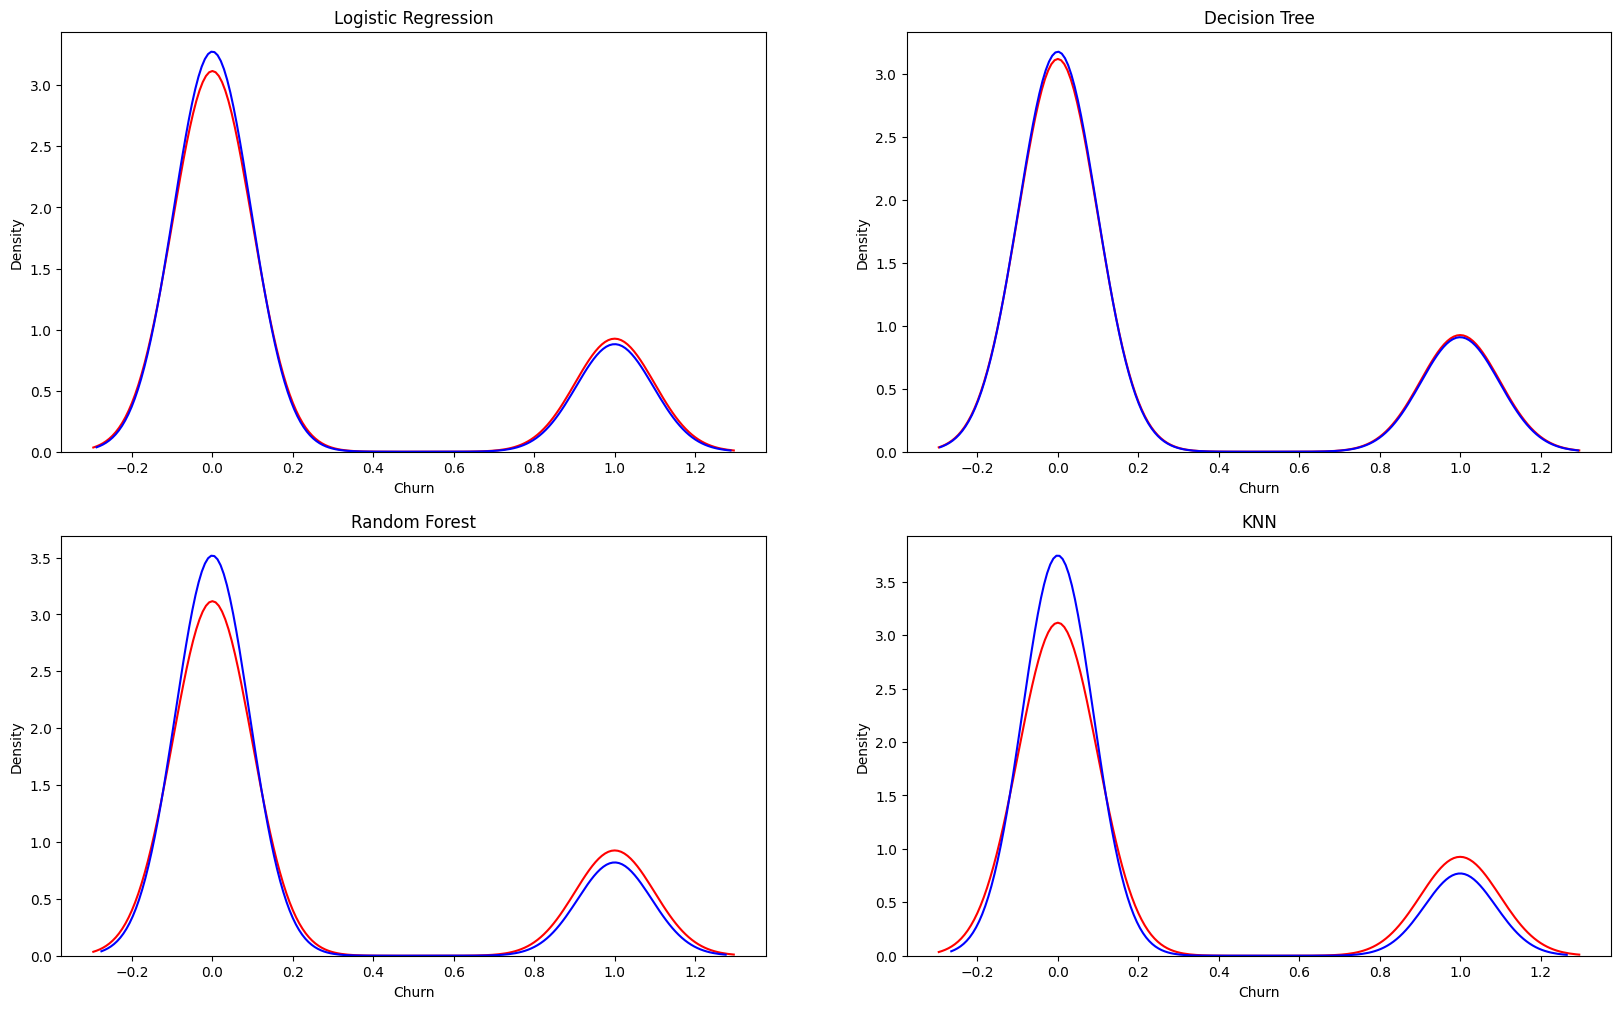

In [ ]:
fig,ax=plt.subplots(2,2,figsize=(20,12))

#Logistic Regression
sns.distplot(y_test,hist=False,color="r",label="Actual Value",ax=ax[0,0]).set_title("Logistic Regression")
sns.distplot(lor_pred,hist=False,color="b",label="Fitted  Value",ax=ax[0,0])

#Decision Tree
sns.distplot(y_test,hist=False,color="r",label="Actual Value",ax=ax[0,1]).set_title("Decision Tree")
sns.distplot(d_pred,hist=False,color="b",label="Fitted  Value",ax=ax[0,1])

#Random Forest
sns.distplot(y_test,hist=False,color='r',label='Actual Values',ax=ax[1,0]).set_title("Random Forest")
sns.distplot(r_pred,hist=False,color='b',label='Fitted Values',ax=ax[1,0])

#KNN
sns.distplot(y_test,hist=False,label='Actual Values',ax=ax[1,1],color='r').set_title("KNN")
sns.distplot(k_pred,hist=False,label='Fitted Values',ax=ax[1,1],color='b')


#**Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print("LOgistic Regression Report : \n",classification_report(y_test,lor_pred))

print("Decision Tree classification Report : \n",classification_report(y_test,d_pred))

print("Random Forest Classification Report: \n",classification_report(y_test,r_pred))

print("KNN classification Report \n",classification_report(y_test,k_pred))

LOgistic Regression Report : 
               precision    recall  f1-score   support

           0       0.88      0.90      0.89      1081
           1       0.62      0.57      0.60       321

    accuracy                           0.82      1402
   macro avg       0.75      0.73      0.74      1402
weighted avg       0.82      0.82      0.82      1402

Decision Tree classification Report : 
               precision    recall  f1-score   support

           0       0.86      0.87      0.86      1081
           1       0.54      0.53      0.53       321

    accuracy                           0.79      1402
   macro avg       0.70      0.70      0.70      1402
weighted avg       0.79      0.79      0.79      1402

Random Forest Classification Report: 
               precision    recall  f1-score   support

           0       0.86      0.91      0.89      1081
           1       0.63      0.52      0.57       321

    accuracy                           0.82      1402
   macro avg      